In [1]:
# Step 1: Setup & Load Data for EDA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# make plots look clean
plt.style.use('seaborn-v0_8')
sns.set_palette('Set2')

# Load cleaned dataset
df = pd.read_csv('E:/CY Tech/Big Data project/Project 1 Car Price Prediction Multiple Linear Regression/Data/Processed/car_price_clean.csv')

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (205, 27)


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,brand
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero
2,3,1,alfa-romero quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi


1- Check for Missing and Duplicate Values:

- Are there any missing entries in the dataset?
- Are there duplicate rows that should be removed?

In [11]:
# Check for missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Check for duplicate rows
print("\nNumber of duplicate rows:", df.duplicated().sum())

Missing values in each column:
car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
brand               0
dtype: int64

Number of duplicate rows: 0


2- Outlier Detection :

- Are there extreme values in price, horsepower, or enginesize?
- Should we remove or cap them?

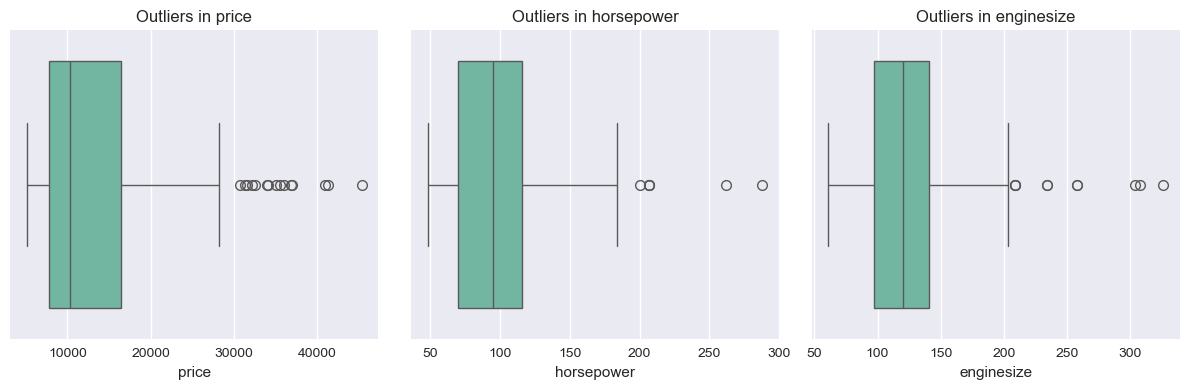

price: lower=-5284.50, upper=29575.50 | below=0, above=15
horsepower: lower=1.00, upper=185.00 | below=0, above=6
enginesize: lower=31.00, upper=207.00 | below=0, above=10


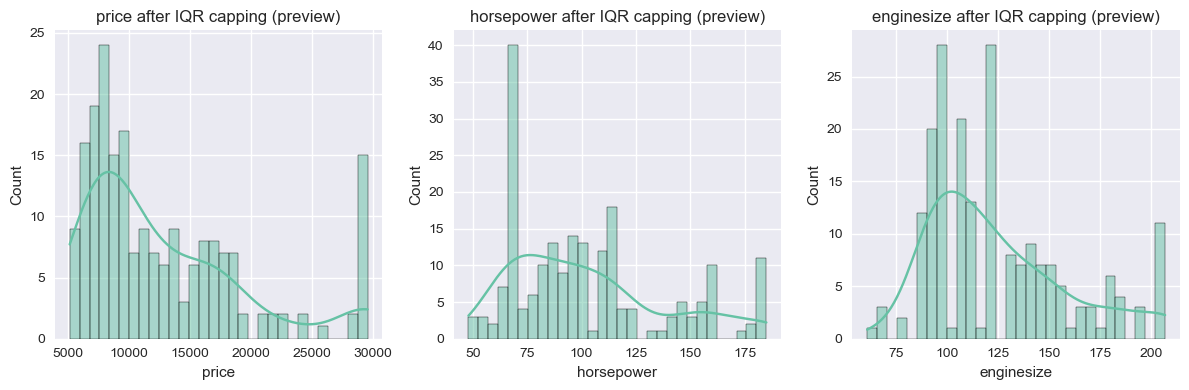

In [12]:
numeric_check = ['price', 'horsepower', 'enginesize']

# Boxplots to visualize outliers
plt.figure(figsize=(12,4))
for i, col in enumerate(numeric_check, 1):
    plt.subplot(1,3,i)
    sns.boxplot(x=df[col])
    plt.title(f'Outliers in {col}')
plt.tight_layout()
plt.show()

# IQR method to flag outliers and suggest caps (no removal yet)
def iqr_bounds(s):
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return lower, upper

for col in numeric_check:
    lo, hi = iqr_bounds(df[col])
    n_low = (df[col] < lo).sum()
    n_high = (df[col] > hi).sum()
    print(f"{col}: lower={lo:.2f}, upper={hi:.2f} | below={n_low}, above={n_high}")

#review winsorized (capped) copies for comparison (not modifying df)
df_winsor_preview = df.copy()
for col in numeric_check:
    lo, hi = iqr_bounds(df[col])
    df_winsor_preview[col] = df[col].clip(lower=lo, upper=hi)

# Quick check of distributions after capping (preview only)
plt.figure(figsize=(12,4))
for i, col in enumerate(numeric_check, 1):
    plt.subplot(1,3,i)
    sns.histplot(df_winsor_preview[col], bins=30, kde=True)
    plt.title(f'{col} after IQR capping (preview)')
plt.tight_layout()
plt.show()

3- Price Distribution:

- Is the price variable skewed?
- Do we need to apply a log transformation to normalize it?

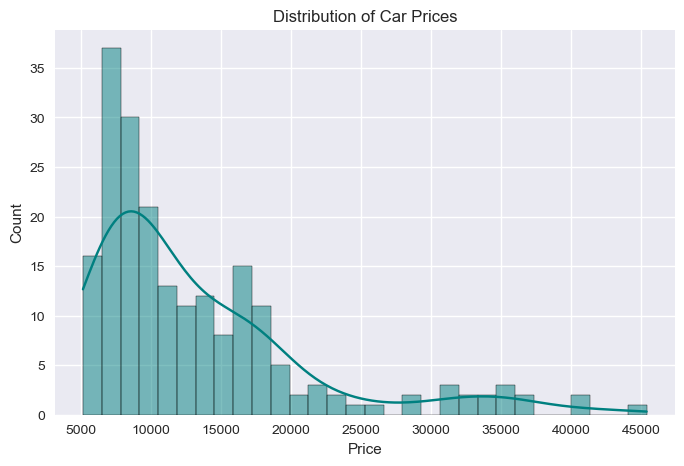

Skewness of price: 1.7776781560914454


In [13]:
# Histogram of price
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=30, kde=True, color='teal')
plt.title('Distribution of Car Prices')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

# Skewness check
print("Skewness of price:", df['price'].skew())

4- Correlation Analysis

- Which numeric variables are most correlated with price?
(horsepower, curbweight, enginesize, citympg)

Top correlations with price:
price         1.000000
enginesize    0.874145
curbweight    0.835305
horsepower    0.808139
carwidth      0.759325
carlength     0.682920
wheelbase     0.577816
boreratio     0.553173
carheight     0.119336
stroke        0.079443
Name: price, dtype: float64


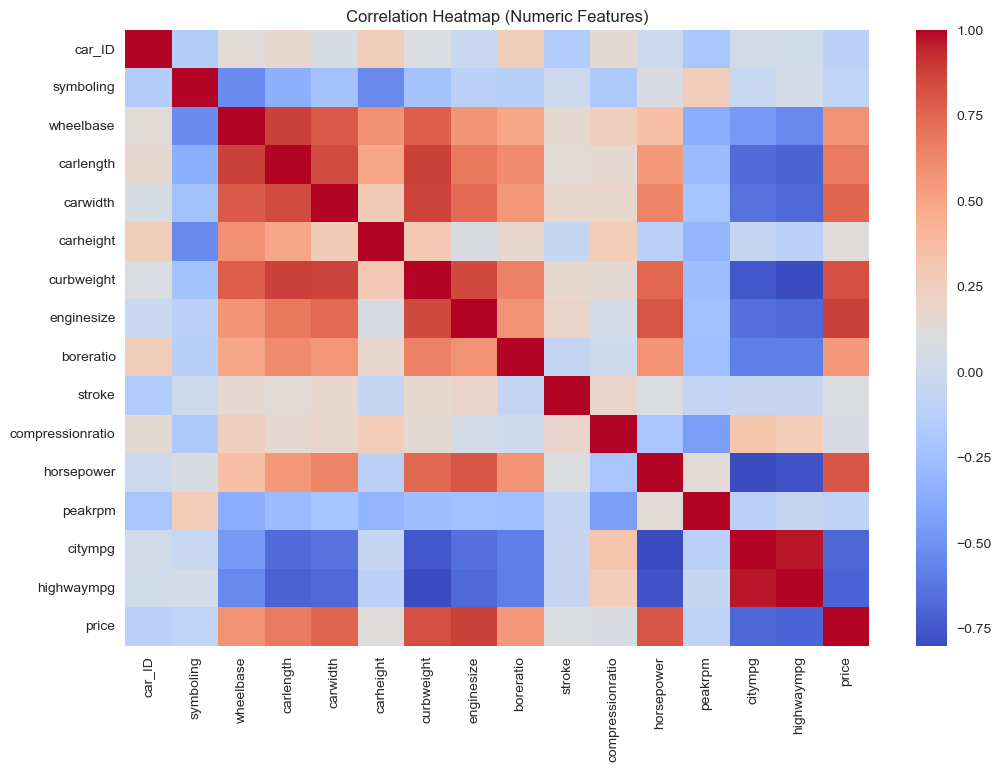

In [15]:
# Correlation with price
corr = df.corr(numeric_only=True)['price'].sort_values(ascending=False)
print("Top correlations with price:")
print(corr.head(10))

# Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap (Numeric Features)')
plt.show()

5- Categorical Feature Impact:

How does price vary by:

- Brand (CarName)
- Fuel Type
- Car Body
- Drive Wheel

C:\Users\fdame\AppData\Local\Temp\ipykernel_24044\1246982796.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='brand', y='price', data=df, ci=None)


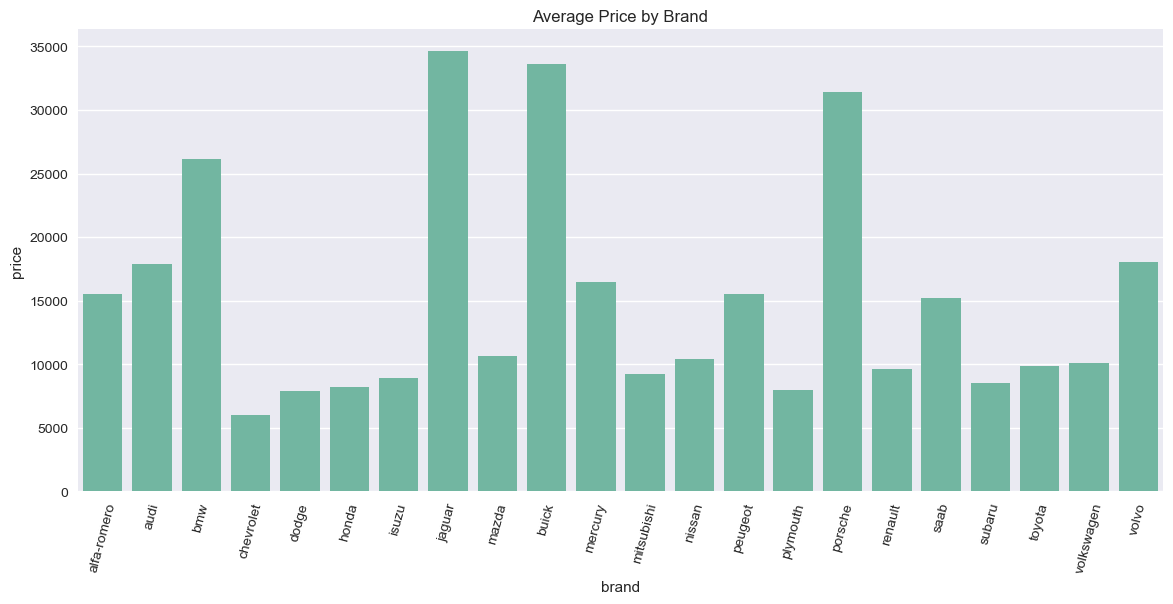

C:\Users\fdame\AppData\Local\Temp\ipykernel_24044\1246982796.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='fueltype', y='price', data=df, ci=None)


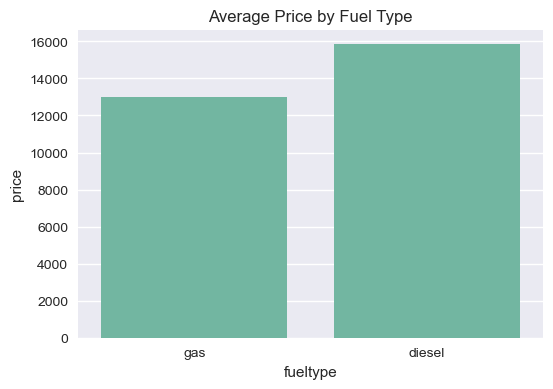

C:\Users\fdame\AppData\Local\Temp\ipykernel_24044\1246982796.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='carbody', y='price', data=df, ci=None)


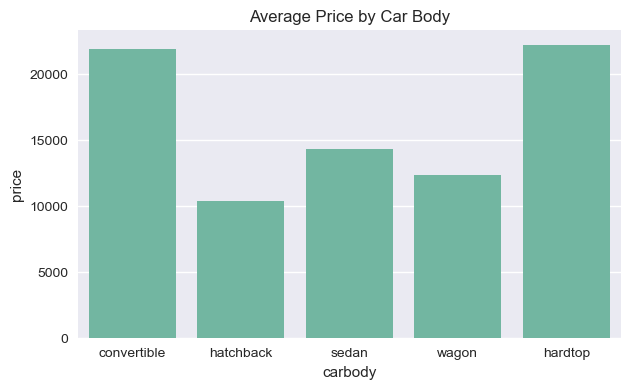

C:\Users\fdame\AppData\Local\Temp\ipykernel_24044\1246982796.py:22: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='drivewheel', y='price', data=df, ci=None)


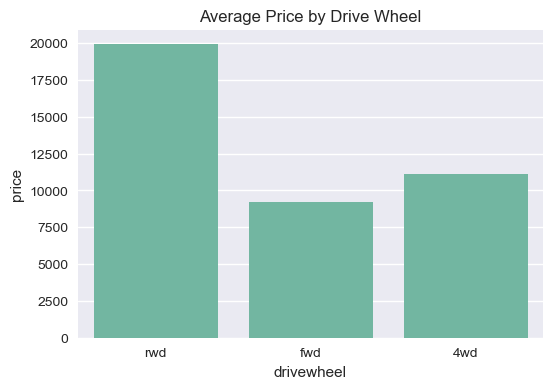

In [16]:
# Price by Brand
plt.figure(figsize=(14,6))
sns.barplot(x='brand', y='price', data=df, ci=None)
plt.xticks(rotation=75)
plt.title('Average Price by Brand')
plt.show()

# Price by Fuel Type
plt.figure(figsize=(6,4))
sns.barplot(x='fueltype', y='price', data=df, ci=None)
plt.title('Average Price by Fuel Type')
plt.show()

# Price by Car Body
plt.figure(figsize=(7,4))
sns.barplot(x='carbody', y='price', data=df, ci=None)
plt.title('Average Price by Car Body')
plt.show()

# Price by Drive Wheel
plt.figure(figsize=(6,4))
sns.barplot(x='drivewheel', y='price', data=df, ci=None)
plt.title('Average Price by Drive Wheel')
plt.show()

6- Feature Relationships:

- Scatterplots and pairplots for key numeric variables vs price.

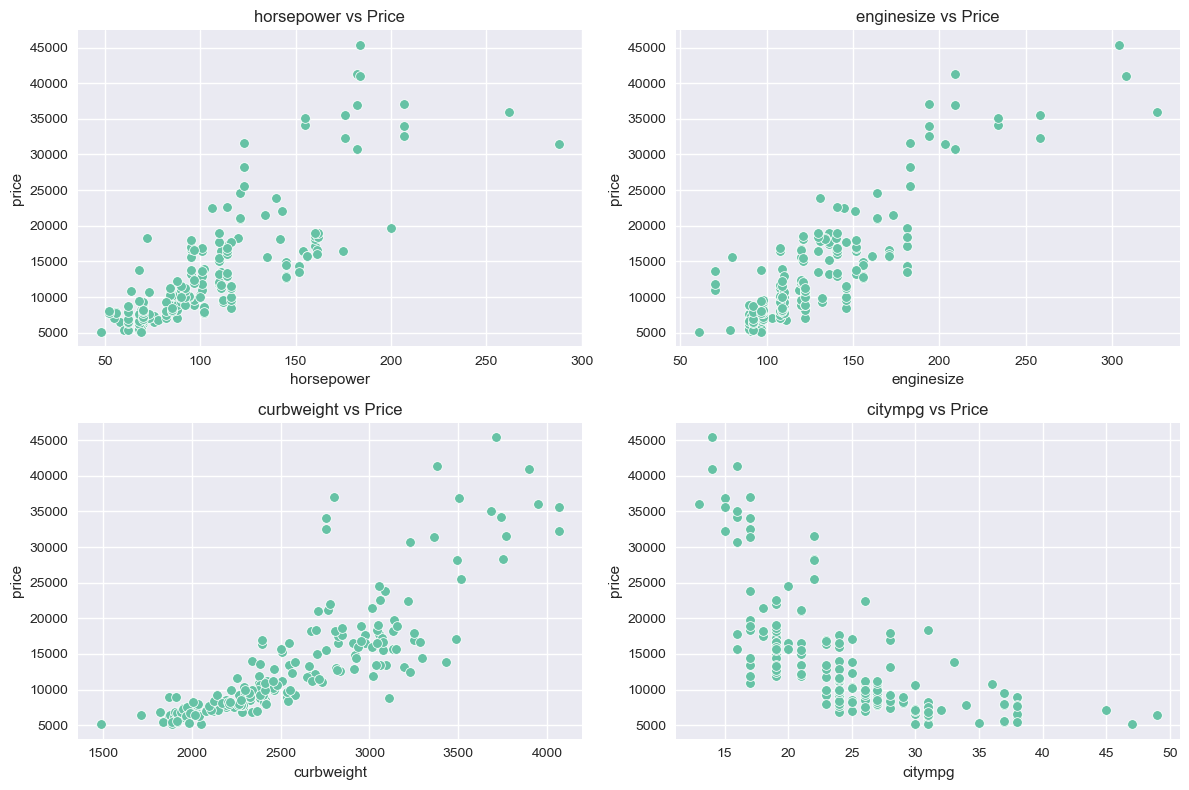

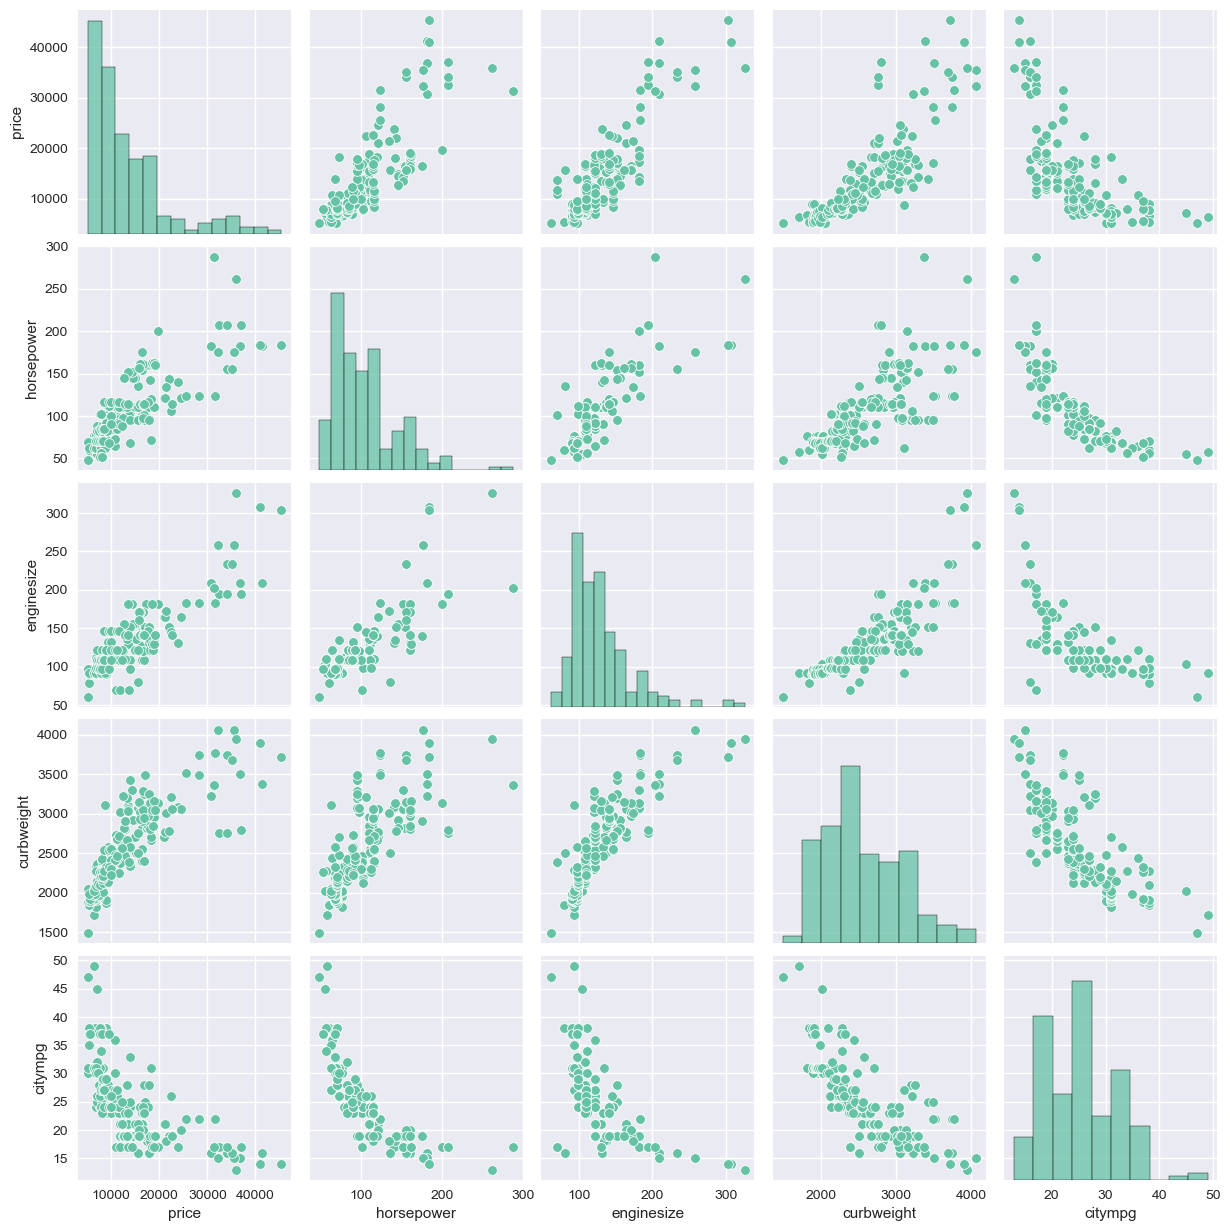

In [17]:
# Scatterplots between key numeric features and price
numeric_features = ['horsepower', 'enginesize', 'curbweight', 'citympg']

plt.figure(figsize=(12,8))
for i, col in enumerate(numeric_features):
    plt.subplot(2,2,i+1)
    sns.scatterplot(x=df[col], y=df['price'])
    plt.title(f'{col} vs Price')
plt.tight_layout()
plt.show()

# Pairplot (optional, more visual)
sns.pairplot(df[['price', 'horsepower', 'enginesize', 'curbweight', 'citympg']])
plt.show()

7- Feature Leakage Check:

- Is there any column that directly or indirectly includes price information?
(derived features that might make prediction too easy)

In [18]:
# Quick manual inspection for suspicious columns
for col in df.columns:
    if 'price' in col.lower():
        print("Potential leakage column:", col)

# Display high correlations to check if any feature is unrealistically predictive
print("\nColumns with correlation > 0.9:")
print(df.corr(numeric_only=True)['price'][df.corr(numeric_only=True)['price'].abs() > 0.9])

Potential leakage column: price

Columns with correlation > 0.9:
price    1.0
Name: price, dtype: float64
